# Task 2 — Autoformer forecasting pipeline

This notebook contains every experiment behind the Task 2 report and the code that produced the leaderboard submissions. All outputs shown are the recorded runs.

**Final model (submission #3, best leaderboard result):** Autoformer encoder–decoder with series decomposition and Auto-Correlation (Section 5), raw target (z-scored), `d_model=32`, `d_ff=64`, all 10 external variables entering the encoder and decoder as marks (including their known values over the 168-step horizon), Huber loss, AdamW with a cosine schedule, three seeds each refitted on the full history and averaged.
Declared **P = 90,819** and **E = 61** are printed at the end of Section 12 and saved in `final_declared.json`.

| Section | Content |
|---|---|
| 1–6 | data checks, periodicity, preprocessing, windows and validation split, model, metrics and training loop |
| 7–8 | covariate-timing ablation (none / past / future) × 3 seeds, with figures (Requirement 4) |
| 9 | early single-seed refit — **not submitted**, kept for the record |
| 10–11 | reference re-run and design experiments (covariate placement and groups, raw vs log target, model size) |
| 12 | **submission #3**: raw-small, 3-seed refit |
| 13 | feature-engineering experiments |
| 14–15 | submissions #4 (fe-dyn) and #5 (fe-dyn + log-target blend) |
| 16 | summary of all submissions |

**Execution notes**
* The experiments ran in two Colab sessions on a GPU. Sections 7–9 come from the first session; Sections 1–6 and 10–15 show the outputs of the second session (Sections 1–6 were re-run at its start). This is why the execution counts are not in order.
* GPU training is not bit-for-bit reproducible: re-running gives slightly different numbers and can change the best epoch, and therefore E. The declared P and E refer to the recorded runs below.
* Cell order now matches a top-to-bottom run. Three small code changes were made after execution, none of which changes any result: Section 13 skips the fe-all completion step when nothing is missing; Section 9 writes to `early_single_seed_*` files so it cannot overwrite the submission files; and `summarize` (Section 11) selects rows with boolean indexing instead of `DataFrame.query`, which fails inside a list comprehension on some Python versions.

**Reference:** model code adapted from the official implementation, https://github.com/thuml/Autoformer (`layers/AutoCorrelation.py`, `layers/Autoformer_EncDec.py`, `models/Autoformer.py`). Wu et al., *Autoformer*, NeurIPS 2021.

In [2]:
import math, random, time, copy, os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

DATA_DIR = '.'
FIG_DIR = 'figures'
os.makedirs(FIG_DIR, exist_ok=True)

CFG = dict(
    seq_len=336, label_len=168, pred_len=168,
    # ---- Part A: capacity + decomposition architecture ----
    d_model=64, n_heads=4, d_ff=128, e_layers=2, d_layers=1,
    moving_avg=25,          # odd kernel ~ one primary cycle (see period detection)
    autocorr_factor=1,      # k = int(c * ln L) delays aggregated
    dropout=0.1,
    # ---- Part B: training ----
    lr=1e-3, eta_min=1e-5, weight_decay=1e-4,
    max_epochs=15, patience=3, batch_size=64, grad_clip=1.0, huber_delta=1.0,
    train_stride=1,         # 1 = every possible window; raise (e.g. 2-4) if CPU-bound
    # ---- validation ----
    n_val_blocks=8,         # last 8*168 = 1344 steps held out
    val_stride=24,          # walk-forward origins inside the held-out region
    target_transform='log1p',  # 'log1p' or 'none'
)
SEEDS = [0, 1, 2]
COV_MODES = ['none', 'past', 'future']   # ablation for Req. 4

QUICK = False   # True = tiny smoke test only
if QUICK:
    CFG.update(max_epochs=2, train_stride=48, d_model=16, d_ff=32)
    SEEDS = [0, 1]

def set_seed(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

device: cuda


## 1. Load data + sanity checks

In [3]:
train_df = pd.read_csv(f'{DATA_DIR}/student_train.csv').sort_values('time_idx').reset_index(drop=True)
test_df = pd.read_csv(f'{DATA_DIR}/student_test.csv').sort_values('time_idx').reset_index(drop=True)
ext_df = pd.read_csv(f'{DATA_DIR}/optional_external_data.csv').sort_values('time_idx').reset_index(drop=True)

y_raw = train_df['value'].to_numpy(dtype=float)
N_TRAIN, N_TOTAL = len(train_df), len(ext_df)
L, LB, H = CFG['seq_len'], CFG['label_len'], CFG['pred_len']

assert N_TRAIN == 43656 and N_TOTAL == 43824, (N_TRAIN, N_TOTAL)
assert (np.diff(train_df['time_idx']) == 1).all() and (np.diff(ext_df['time_idx']) == 1).all()
assert len(test_df) == H and test_df['time_idx'].iloc[0] == N_TRAIN + 1 and test_df['time_idx'].iloc[-1] == N_TOTAL
assert not np.isnan(y_raw).any() and (y_raw >= 0).all()

COV_COLS = [c for c in ext_df.columns if c != 'time_idx']
BIN_COLS = [c for c in COV_COLS if set(np.unique(ext_df[c])) <= {0, 1}]
CONT_COLS = [c for c in COV_COLS if c not in BIN_COLS]
print('binary :', BIN_COLS, '| one-hot rows sum to 1:', bool((ext_df[BIN_COLS].sum(1) == 1).all()) if BIN_COLS else None)
print('continuous:', CONT_COLS)
print(pd.Series(y_raw).describe().round(2).to_dict())

binary : ['feature_G', 'feature_H', 'feature_I', 'feature_J'] | one-hot rows sum to 1: True
continuous: ['feature_A', 'feature_B', 'feature_C', 'feature_D', 'feature_E', 'feature_F']
{'count': 43656.0, 'mean': 98.17, 'std': 90.83, 'min': 0.0, '25%': 30.0, '50%': 73.0, '75%': 136.0, 'max': 994.0}


## 2. Recover periodic structure (no calendar available)
ACF peaks and FFT periods of `log1p(value)`. These set `moving_avg` and the seasonal-naive baselines.

top ACF peaks (lag, acf): [(528, 0.066), (337, 0.06), (745, 0.053), (505, 0.05), (359, 0.047), (720, 0.045), (192, 0.044), (312, 0.043)]
top FFT periods: [  269.5 10914.    183.4   386.3    24.    338.4   379.6   289.1]
seasonal-naive periods: [24]


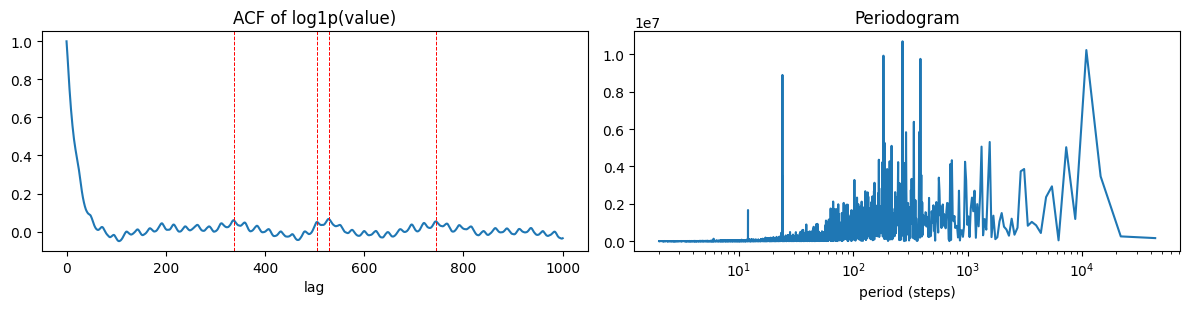

In [4]:
def acf(x, max_lag):
    x = x - x.mean()
    f = np.fft.rfft(x, n=2 * len(x))
    ac = np.fft.irfft(f * np.conj(f))[:max_lag + 1]
    return ac / ac[0]

ly = np.log1p(y_raw)
ac = acf(ly, 1000)
peaks = [l for l in range(2, 1000) if ac[l] > ac[l - 1] and ac[l] >= ac[l + 1]]
top_acf = sorted(peaks, key=lambda l: -ac[l])[:8]
print('top ACF peaks (lag, acf):', [(l, round(float(ac[l]), 3)) for l in top_acf])

spec = np.abs(np.fft.rfft(ly - ly.mean())) ** 2
freqs = np.fft.rfftfreq(len(ly))
top_f = np.argsort(spec[1:])[::-1][:8] + 1
print('top FFT periods:', np.round(1 / freqs[top_f], 1))

# seasonal-naive periods for the baselines: strongest ACF peaks <= horizon
NAIVE_PERIODS = sorted({l for l in top_acf if l <= H}, key=lambda l: -ac[l])[:2] or [24]
print('seasonal-naive periods:', NAIVE_PERIODS)

fig, ax = plt.subplots(1, 2, figsize=(12, 3.2))
ax[0].plot(ac); ax[0].set_xlabel('lag'); ax[0].set_title('ACF of log1p(value)')
for l in top_acf[:4]:
    ax[0].axvline(l, ls='--', lw=0.7, c='r')
ax[1].semilogx(1 / freqs[1:], spec[1:]); ax[1].set_xlabel('period (steps)'); ax[1].set_title('Periodogram')
plt.tight_layout(); plt.savefig(f'{FIG_DIR}/fig_t2_1_periodicity.pdf'); plt.show()

## 3. Preprocessing
* Target: `log1p` then z-score, with stats fit on **training-only** steps (`fit_end`).
* Covariates: continuous columns z-scored (same `fit_end`). Binary one-hot columns stay 0/1.

The log transform is used up to Section 10. From Section 11 on, the final models use `target_transform='none'` (z-scored raw values), which gave a lower RMSE.

In [7]:
class TargetScaler:
    def __init__(self, transform):
        self.transform_name = transform
    def _fwd(self, y):
        return np.log1p(y) if self.transform_name == 'log1p' else y
    def fit(self, y):
        z = self._fwd(y)
        self.mu, self.sd = z.mean(), z.std()
        return self
    def transform(self, y):
        return (self._fwd(y) - self.mu) / self.sd
    def inverse(self, z):
        v = z * self.sd + self.mu
        if self.transform_name == 'log1p':
            v = np.expm1(v)
        return np.clip(v, 0, None)   # non-negative physical quantity

def prepare(fit_end):
    ysc = TargetScaler(CFG['target_transform']).fit(y_raw[:fit_end])
    y_s = ysc.transform(y_raw).astype(np.float32)
    cov = ext_df[COV_COLS].to_numpy(dtype=float).copy()
    ci = [COV_COLS.index(c) for c in CONT_COLS]
    if ci:
        mu, sd = cov[:fit_end, ci].mean(0), cov[:fit_end, ci].std(0)
        sd[sd == 0] = 1.0
        cov[:, ci] = (cov[:, ci] - mu) / sd
    return y_s, cov.astype(np.float32), ysc

## 4. Windows and the chronological validation split
A window with forecast origin `o` uses encoder `[o-L, o)`, decoder `[o-label_len, o+H)` and target `[o, o+H)`.

Covariate modes (ablation):
* `none`: target only.
* `past`: covariates in the encoder and the decoder's label part. Future rows are zeroed, i.e. "not known".
* `future`: covariates over the 168-step horizon are also given to the decoder. The brief allows this (Sec. 2.3).

Train origins only allow targets that end **before** `VAL_START`. Validation origins cover the last 1,344 steps, every 24 steps.

In [8]:
class WindowDataset(Dataset):
    def __init__(self, y_s, cov, origins, cov_mode):
        self.y, self.cov, self.origins, self.mode = y_s, cov, np.asarray(origins), cov_mode

    def __len__(self):
        return len(self.origins)

    def __getitem__(self, i):
        o = int(self.origins[i])
        x_enc = self.y[o - L:o, None]
        y_true = self.y[o:o + H, None] if o + H <= len(self.y) else np.zeros((H, 1), np.float32)
        if self.mode == 'none':
            m_enc, m_dec = np.zeros((L, 0), np.float32), np.zeros((LB + H, 0), np.float32)
        else:
            m_enc = self.cov[o - L:o]
            m_dec = self.cov[o - LB:o + H].copy()
            if self.mode == 'past':
                m_dec[LB:] = 0.0
        return tuple(torch.from_numpy(np.ascontiguousarray(a)) for a in (x_enc, m_enc, m_dec, y_true))

VAL_START = N_TRAIN - CFG['n_val_blocks'] * H
train_origins = np.arange(L, VAL_START - H + 1, CFG['train_stride'])
val_origins = np.arange(VAL_START, N_TRAIN - H + 1, CFG['val_stride'])
block_origins = np.arange(VAL_START, N_TRAIN - H + 1, H)   # non-overlapping 168-blocks
print(f'VAL_START={VAL_START} (time_idx {VAL_START+1}) | train windows={len(train_origins)} | '
      f'val windows={len(val_origins)} | val blocks={len(block_origins)}')

VAL_START=42312 (time_idx 42313) | train windows=41809 | val windows=50 | val blocks=8


## 5. Autoformer (adapted from thuml/Autoformer)
* **Series decomposition** (`SeriesDecomp`): moving-average trend and the seasonal residual. It is used on the input, after every Auto-Correlation and after every FFN in the encoder and decoder.
* **Auto-Correlation** (`AutoCorrelation`): computes the per-lag correlation `R(τ)` with FFT (Wiener–Khinchin). It keeps the top-`k = ⌊c·ln L⌋` delays, applies softmax to their scores, and sums the values rolled by those delays. There is no point-wise dot-product attention.
* **Decoder:** the seasonal branch is refined layer by layer. The trend branch starts from the input trend plus the input mean, and each decoder layer adds the trend it removed.

In [9]:
class MovingAvg(nn.Module):
    def __init__(self, kernel_size):
        super().__init__()
        self.k = kernel_size
        self.avg = nn.AvgPool1d(kernel_size, stride=1, padding=0)

    def forward(self, x):                               # x: [B, T, C]
        pad = (self.k - 1) // 2
        x = torch.cat([x[:, :1].repeat(1, pad, 1), x, x[:, -1:].repeat(1, pad, 1)], dim=1)
        return self.avg(x.permute(0, 2, 1)).permute(0, 2, 1)


class SeriesDecomp(nn.Module):
    def __init__(self, kernel_size):
        super().__init__()
        self.ma = MovingAvg(kernel_size)

    def forward(self, x):
        trend = self.ma(x)
        return x - trend, trend                          # seasonal, trend


class AutoCorrelation(nn.Module):
    def __init__(self, factor=1, dropout=0.1):
        super().__init__()
        self.factor = factor
        self.dropout = nn.Dropout(dropout)

    def time_delay_agg(self, values, corr):
        # values, corr: [B, H, E, T]; per-sample top-k delays (thuml "inference" variant, used in train too)
        B, Hh, E, T = values.shape
        top_k = max(1, int(self.factor * math.log(T)))
        mean_corr = corr.mean(dim=(1, 2))                                 # [B, T]
        weights, delay = torch.topk(mean_corr, top_k, dim=-1)            # [B, k]
        weights = self.dropout(torch.softmax(weights, dim=-1))
        init_index = torch.arange(T, device=values.device).view(1, 1, 1, T).expand(B, Hh, E, T)
        tmp_values = values.repeat(1, 1, 1, 2)
        agg = torch.zeros_like(values)
        for i in range(top_k):
            idx = init_index + delay[:, i].view(B, 1, 1, 1)
            agg = agg + torch.gather(tmp_values, -1, idx) * weights[:, i].view(B, 1, 1, 1)
        return agg

    def forward(self, q, k, v):                         # [B, T, H, E]
        B, Tq, Hh, E = q.shape
        S = k.shape[1]
        if Tq > S:
            zeros = torch.zeros_like(q[:, :Tq - S])
            k, v = torch.cat([k, zeros], 1), torch.cat([v, zeros], 1)
        else:
            k, v = k[:, :Tq], v[:, :Tq]
        q_fft = torch.fft.rfft(q.permute(0, 2, 3, 1).contiguous(), dim=-1)
        k_fft = torch.fft.rfft(k.permute(0, 2, 3, 1).contiguous(), dim=-1)
        corr = torch.fft.irfft(q_fft * torch.conj(k_fft), n=Tq, dim=-1)
        out = self.time_delay_agg(v.permute(0, 2, 3, 1).contiguous(), corr)
        return out.permute(0, 3, 1, 2)                   # [B, T, H, E]


class AutoCorrelationLayer(nn.Module):
    def __init__(self, d_model, n_heads, factor, dropout):
        super().__init__()
        self.h = n_heads
        self.inner = AutoCorrelation(factor, dropout)
        self.q, self.k, self.v, self.o = (nn.Linear(d_model, d_model) for _ in range(4))

    def forward(self, xq, xk, xv):
        B, Tq, _ = xq.shape
        S = xk.shape[1]
        q = self.q(xq).view(B, Tq, self.h, -1)
        k = self.k(xk).view(B, S, self.h, -1)
        v = self.v(xv).view(B, S, self.h, -1)
        return self.o(self.inner(q, k, v).reshape(B, Tq, -1))


class SeasonalLayerNorm(nn.Module):
    # LayerNorm, then subtract the temporal mean (thuml `my_Layernorm`)
    def __init__(self, d_model):
        super().__init__()
        self.ln = nn.LayerNorm(d_model)

    def forward(self, x):
        x = self.ln(x)
        return x - x.mean(dim=1, keepdim=True)


class DataEmbedding(nn.Module):
    # value embedding (circular conv) + covariate "mark" embedding; no positional encoding (as in Autoformer)
    def __init__(self, c_in, mark_dim, d_model, dropout):
        super().__init__()
        self.value = nn.Conv1d(c_in, d_model, 3, padding=1, padding_mode='circular', bias=False)
        self.mark = nn.Linear(mark_dim, d_model, bias=False) if mark_dim > 0 else None
        self.drop = nn.Dropout(dropout)

    def forward(self, x, x_mark):
        out = self.value(x.permute(0, 2, 1)).transpose(1, 2)
        if self.mark is not None:
            out = out + self.mark(x_mark)
        return self.drop(out)


class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, moving_avg, factor, dropout):
        super().__init__()
        self.attn = AutoCorrelationLayer(d_model, n_heads, factor, dropout)
        self.ff1 = nn.Conv1d(d_model, d_ff, 1, bias=False)
        self.ff2 = nn.Conv1d(d_ff, d_model, 1, bias=False)
        self.decomp1, self.decomp2 = SeriesDecomp(moving_avg), SeriesDecomp(moving_avg)
        self.drop = nn.Dropout(dropout)
        self.act = nn.GELU()

    def forward(self, x):
        x, _ = self.decomp1(x + self.drop(self.attn(x, x, x)))
        y = self.drop(self.act(self.ff1(x.transpose(1, 2))))
        y = self.drop(self.ff2(y).transpose(1, 2))
        x, _ = self.decomp2(x + y)
        return x


class DecoderLayer(nn.Module):
    def __init__(self, d_model, c_out, n_heads, d_ff, moving_avg, factor, dropout):
        super().__init__()
        self.self_attn = AutoCorrelationLayer(d_model, n_heads, factor, dropout)
        self.cross_attn = AutoCorrelationLayer(d_model, n_heads, factor, dropout)
        self.ff1 = nn.Conv1d(d_model, d_ff, 1, bias=False)
        self.ff2 = nn.Conv1d(d_ff, d_model, 1, bias=False)
        self.decomp1, self.decomp2, self.decomp3 = (SeriesDecomp(moving_avg) for _ in range(3))
        self.trend_proj = nn.Conv1d(d_model, c_out, 3, padding=1, padding_mode='circular', bias=False)
        self.drop = nn.Dropout(dropout)
        self.act = nn.GELU()

    def forward(self, x, cross):
        x, t1 = self.decomp1(x + self.drop(self.self_attn(x, x, x)))
        x, t2 = self.decomp2(x + self.drop(self.cross_attn(x, cross, cross)))
        y = self.drop(self.act(self.ff1(x.transpose(1, 2))))
        y = self.drop(self.ff2(y).transpose(1, 2))
        x, t3 = self.decomp3(x + y)
        trend = self.trend_proj((t1 + t2 + t3).permute(0, 2, 1)).transpose(1, 2)
        return x, trend


class Autoformer(nn.Module):
    def __init__(self, mark_dim, c_in=1, c_out=1, d_model=64, n_heads=4, d_ff=128,
                 e_layers=2, d_layers=1, moving_avg=25, factor=1, dropout=0.1):
        super().__init__()
        self.decomp = SeriesDecomp(moving_avg)
        self.enc_emb = DataEmbedding(c_in, mark_dim, d_model, dropout)
        self.dec_emb = DataEmbedding(c_in, mark_dim, d_model, dropout)
        self.encoder = nn.ModuleList(EncoderLayer(d_model, n_heads, d_ff, moving_avg, factor, dropout)
                                     for _ in range(e_layers))
        self.enc_norm = SeasonalLayerNorm(d_model)
        self.decoder = nn.ModuleList(DecoderLayer(d_model, c_out, n_heads, d_ff, moving_avg, factor, dropout)
                                     for _ in range(d_layers))
        self.dec_norm = SeasonalLayerNorm(d_model)
        self.proj = nn.Linear(d_model, c_out)

    def forward(self, x_enc, m_enc, m_dec):
        # decoder init: seasonal = last label_len of input seasonal + zeros; trend = input trend + input mean
        mean = x_enc.mean(dim=1, keepdim=True).repeat(1, H, 1)
        zeros = torch.zeros(x_enc.shape[0], H, x_enc.shape[2], device=x_enc.device)
        seasonal, trend = self.decomp(x_enc)
        trend = torch.cat([trend[:, -LB:], mean], dim=1)
        seasonal = torch.cat([seasonal[:, -LB:], zeros], dim=1)

        enc = self.enc_emb(x_enc, m_enc)
        for layer in self.encoder:
            enc = layer(enc)
        enc = self.enc_norm(enc)

        dec = self.dec_emb(seasonal, m_dec)
        for layer in self.decoder:
            dec, residual_trend = layer(dec, enc)
            trend = trend + residual_trend
        dec = self.proj(self.dec_norm(dec))
        return (trend + dec)[:, -H:]


def build_model(cov_mode):
    return Autoformer(mark_dim=0 if cov_mode == 'none' else len(COV_COLS),
                      d_model=CFG['d_model'], n_heads=CFG['n_heads'], d_ff=CFG['d_ff'],
                      e_layers=CFG['e_layers'], d_layers=CFG['d_layers'], moving_avg=CFG['moving_avg'],
                      factor=CFG['autocorr_factor'], dropout=CFG['dropout']).to(device)

count_params = lambda m: sum(p.numel() for p in m.parameters() if p.requires_grad)
for mode in COV_MODES:
    print(f'P[{mode}] = {count_params(build_model(mode)):,}')
print('Auto-Correlation k =', max(1, int(CFG['autocorr_factor'] * math.log(L))), 'delays (encoder, L=336)')

P[none] = 116,609
P[past] = 117,889
P[future] = 117,889
Auto-Correlation k = 5 delays (encoder, L=336)


## 6. Metrics (raw units) and training loop (Part B)
* **Loss:** Huber (SmoothL1) on the scaled log target. It is robust to the order-of-magnitude spikes.
* **Optimiser:** AdamW, lr 1e-3, weight decay 1e-4. Cosine annealing to 1e-5 over `max_epochs`. Grad-norm clip 1.0.
* **Selection:** best-val-RMSE checkpoint, early-stopping patience 3.
* **Per epoch:** train MAE/RMSE/sMAPE on one training window every 168 steps (~250 windows) and val MAE/RMSE/sMAPE. All in original units after `expm1`.

`train_model` is shared by every experiment; the settings it reads from `CFG` are changed per experiment by `run_variant` (Section 11).

In [10]:
def metrics(pred, true):
    err = pred - true
    denom = np.abs(true) + np.abs(pred)
    sm = np.where(denom == 0, 0.0, 2 * np.abs(err) / np.where(denom == 0, 1.0, denom))
    return dict(MAE=float(np.abs(err).mean()), RMSE=float(np.sqrt((err ** 2).mean())), sMAPE=float(100 * sm.mean()))

@torch.no_grad()
def predict(model, ds, ysc, bs=256):
    model.eval()
    out = []
    for x_enc, m_enc, m_dec, _ in DataLoader(ds, batch_size=bs, shuffle=False):
        out.append(model(x_enc.to(device), m_enc.to(device), m_dec.to(device)).cpu().numpy()[..., 0])
    return ysc.inverse(np.concatenate(out))

def truth(origins):
    return np.stack([y_raw[o:o + H] for o in origins])

def train_model(seed, cov_mode, y_s, cov, ysc, tr_origins, va_origins=None, n_epochs=None, tag=''):
    set_seed(seed)
    loader = DataLoader(WindowDataset(y_s, cov, tr_origins, cov_mode), batch_size=CFG['batch_size'],
                        shuffle=True, generator=torch.Generator().manual_seed(seed))
    tr_eval_orig = tr_origins[::max(1, H // CFG['train_stride'])]
    tr_eval = WindowDataset(y_s, cov, tr_eval_orig, cov_mode)
    va_ds = WindowDataset(y_s, cov, va_origins, cov_mode) if va_origins is not None else None

    model = build_model(cov_mode)
    opt = torch.optim.AdamW(model.parameters(), lr=CFG['lr'], weight_decay=CFG['weight_decay'])
    # T_max fixed to max_epochs so a refit for e epochs follows the same LR path as the selection run
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=CFG['max_epochs'], eta_min=CFG['eta_min'])
    crit = nn.HuberLoss(delta=CFG['huber_delta'])
    n_epochs = n_epochs or CFG['max_epochs']

    hist, best_rmse, best_state, best_epoch, bad = [], float('inf'), None, 0, 0
    for ep in range(1, n_epochs + 1):
        model.train()
        t0, tot, nb = time.time(), 0.0, 0
        for x_enc, m_enc, m_dec, y in loader:
            x_enc, m_enc, m_dec, y = (t.to(device) for t in (x_enc, m_enc, m_dec, y))
            opt.zero_grad()
            loss = crit(model(x_enc, m_enc, m_dec), y)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), CFG['grad_clip'])
            opt.step()
            tot += loss.item(); nb += 1
        sched.step()

        tr = metrics(predict(model, tr_eval, ysc), truth(tr_eval_orig))
        row = dict(epoch=ep, loss=tot / nb, lr=opt.param_groups[0]['lr'], **{f'train_{k}': v for k, v in tr.items()})
        msg = (f'{tag} ep {ep:02d} | loss {row["loss"]:.4f} | train RMSE {tr["RMSE"]:.2f} '
               f'MAE {tr["MAE"]:.2f} sMAPE {tr["sMAPE"]:.1f}')
        if va_ds is not None:
            va = metrics(predict(model, va_ds, ysc), truth(va_origins))
            row.update({f'val_{k}': v for k, v in va.items()})
            msg += f' || val RMSE {va["RMSE"]:.2f} MAE {va["MAE"]:.2f} sMAPE {va["sMAPE"]:.1f}'
            if va['RMSE'] < best_rmse:
                best_rmse, best_state, best_epoch, bad = va['RMSE'], copy.deepcopy(model.state_dict()), ep, 0
                msg += '  *'
            else:
                bad += 1
        hist.append(row)
        print(msg + f' | {time.time() - t0:.0f}s')
        if va_ds is not None and bad >= CFG['patience']:
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    else:
        best_epoch = ep
    return model, pd.DataFrame(hist), dict(best_epoch=best_epoch, epochs_run=ep)

## 7. Covariate-timing ablation × 3 seeds (Requirements 3 & 4) — first session
Default `CFG` (log target, `d_model=64`). Every run sees exactly the same training windows and validation origins; the naive baselines are computed on the same origins.

In [10]:
y_s_v, cov_v, ysc_v = prepare(VAL_START)          # scalers see nothing from the validation region
val_true = truth(val_origins)
blk_idx = np.searchsorted(val_origins, block_origins)

results, histories, val_preds, run_info, states = [], {}, {}, {}, {}
for mode in COV_MODES:
    for seed in SEEDS:
        tag = f'[{mode:6s} s{seed}]'
        model, hist, info = train_model(seed, mode, y_s_v, cov_v, ysc_v, train_origins, val_origins, tag=tag)
        pred = predict(model, WindowDataset(y_s_v, cov_v, val_origins, mode), ysc_v)
        m = metrics(pred, val_true)
        blocks = [metrics(pred[i], val_true[i])['RMSE'] for i in blk_idx]
        results.append(dict(mode=mode, seed=seed, **m, block_RMSE_mean=np.mean(blocks),
                            block_RMSE_std=np.std(blocks), P=count_params(model), **info))
        histories[(mode, seed)], val_preds[(mode, seed)], run_info[(mode, seed)] = hist, pred, info
        states[(mode, seed)] = copy.deepcopy(model.state_dict())

res = pd.DataFrame(results)
res

[none   s0] ep 01 | loss 0.4526 | train RMSE 97.12 MAE 74.35 sMAPE 75.7 || val RMSE 118.81 MAE 93.91 sMAPE 100.3  * | 36s
[none   s0] ep 02 | loss 0.4406 | train RMSE 102.93 MAE 80.28 sMAPE 77.7 || val RMSE 124.45 MAE 100.14 sMAPE 101.6 | 32s
[none   s0] ep 03 | loss 0.4336 | train RMSE 97.70 MAE 74.67 sMAPE 74.8 || val RMSE 116.56 MAE 92.86 sMAPE 98.3  * | 32s
[none   s0] ep 04 | loss 0.4277 | train RMSE 96.04 MAE 72.15 sMAPE 73.1 || val RMSE 115.91 MAE 91.30 sMAPE 97.9  * | 33s
[none   s0] ep 05 | loss 0.4235 | train RMSE 89.73 MAE 64.59 sMAPE 70.3 || val RMSE 113.90 MAE 86.00 sMAPE 97.6  * | 33s
[none   s0] ep 06 | loss 0.4178 | train RMSE 93.87 MAE 68.17 sMAPE 70.8 || val RMSE 118.78 MAE 92.16 sMAPE 98.8 | 33s
[none   s0] ep 07 | loss 0.4120 | train RMSE 91.47 MAE 68.07 sMAPE 70.7 || val RMSE 119.82 MAE 94.85 sMAPE 98.7 | 33s
[none   s0] ep 08 | loss 0.4061 | train RMSE 88.30 MAE 63.83 sMAPE 68.4 || val RMSE 119.19 MAE 92.48 sMAPE 98.2 | 36s
[none   s1] ep 01 | loss 0.4556 | train 

,mode,seed,MAE,RMSE,sMAPE,block_RMSE_mean,block_RMSE_std,P,best_epoch,epochs_run
0,none,0,86.000783,113.896377,97.565553,100.097998,32.675446,116609,5,8
1,none,1,80.031413,110.205362,94.611432,94.875363,33.751163,116609,7,10
2,none,2,78.407168,104.442144,93.024414,93.427702,31.918306,116609,10,13
3,past,0,83.764335,117.031859,96.452873,105.431976,39.376144,117889,1,4
4,past,1,88.807573,123.129541,96.518252,108.008077,35.684814,117889,3,6
5,past,2,82.899015,120.849344,94.901683,102.763082,38.040456,117889,1,4
6,future,0,51.264390,79.264860,58.748620,67.565002,21.951890,117889,3,6
7,future,1,48.387904,76.755417,56.887465,64.664791,18.138592,117889,5,8
8,future,2,53.510926,83.826651,60.269191,74.355731,24.831854,117889,2,5


In [11]:
# ---- naive baselines on the same validation origins ----
base_rows = [dict(mode='persistence', **metrics(np.stack([np.full(H, y_raw[o - 1]) for o in val_origins]), val_true))]
for p in NAIVE_PERIODS:
    sn = np.stack([[y_raw[o - p + (h % p)] for h in range(H)] for o in val_origins])
    base_rows.append(dict(mode=f'seasonal-naive({p})', **metrics(sn, val_true)))
baselines = pd.DataFrame(base_rows)

# ---- summary: mean ± std across seeds, plus seed-ensemble ----
summary = res.groupby('mode', sort=False)[['RMSE', 'MAE', 'sMAPE', 'block_RMSE_std', 'best_epoch', 'epochs_run']].agg(['mean', 'std'])
ens = pd.DataFrame([dict(mode=m, **metrics(np.mean([val_preds[(m, s)] for s in SEEDS], 0), val_true))
                    for m in COV_MODES]).set_index('mode').add_prefix('ensemble_')
print('Validation (last 1,344 steps, 50 walk-forward origins), mean ± std over seeds')
display(summary.round(2))
display(ens.round(2))
display(baselines.round(2))

Validation (last 1,344 steps, 50 walk-forward origins), mean ± std over seeds


RMSE          MAE        sMAPE       block_RMSE_std        \
          mean   std   mean   std   mean   std           mean   std   
mode                                                                  
none    109.51  4.76  81.48  4.00  95.07  2.30          32.78  0.92   
past    120.34  3.08  85.16  3.19  95.96  0.92          37.70  1.87   
future   79.95  3.58  51.05  2.57  58.64  1.69          21.64  3.36   

       best_epoch       epochs_run        
             mean   std       mean   std  
mode                                      
none         7.33  2.52      10.33  2.52  
past         1.67  1.15       4.67  1.15  
future       3.33  1.53       6.33  1.53

,ensemble_MAE,ensemble_RMSE,ensemble_sMAPE
mode,,,
none,80.29,107.68,94.52
past,83.46,117.65,95.40
future,48.90,76.52,57.19


,mode,MAE,RMSE,sMAPE
0,persistence,113.98,155.35,105.03
1,seasonal-naive(24),106.26,145.53,107.26


In [12]:
# ---- paired comparison vs. no covariates (same seed => same init/batch order) ----
rows = []
for mode in COV_MODES[1:]:
    d_rmse = [res.query('mode==@mode and seed==@s').RMSE.item() - res.query('mode=="none" and seed==@s').RMSE.item()
              for s in SEEDS]
    # per-window: fraction of validation windows where this mode beats 'none' (averaged over seeds)
    win = np.mean([np.mean(np.sqrt(((val_preds[(mode, s)] - val_true) ** 2).mean(1)) <
                           np.sqrt(((val_preds[('none', s)] - val_true) ** 2).mean(1))) for s in SEEDS])
    rows.append(dict(mode=mode, dRMSE_mean=np.mean(d_rmse), dRMSE_std=np.std(d_rmse, ddof=1) if len(d_rmse) > 1 else np.nan,
                     seeds_improved=f'{sum(d < 0 for d in d_rmse)}/{len(SEEDS)}', frac_windows_better=win))
paired = pd.DataFrame(rows)
print('ΔRMSE < 0 means covariates help. Compare |dRMSE_mean| to dRMSE_std before claiming anything.')
paired.round(3)

ΔRMSE < 0 means covariates help. Compare |dRMSE_mean| to dRMSE_std before claiming anything.


,mode,dRMSE_mean,dRMSE_std,seeds_improved,frac_windows_better
0,past,10.822,6.881,0/3,0.220
1,future,-29.566,7.774,3/3,0.893


## 8. Figures: learning curves, ablation, example forecast

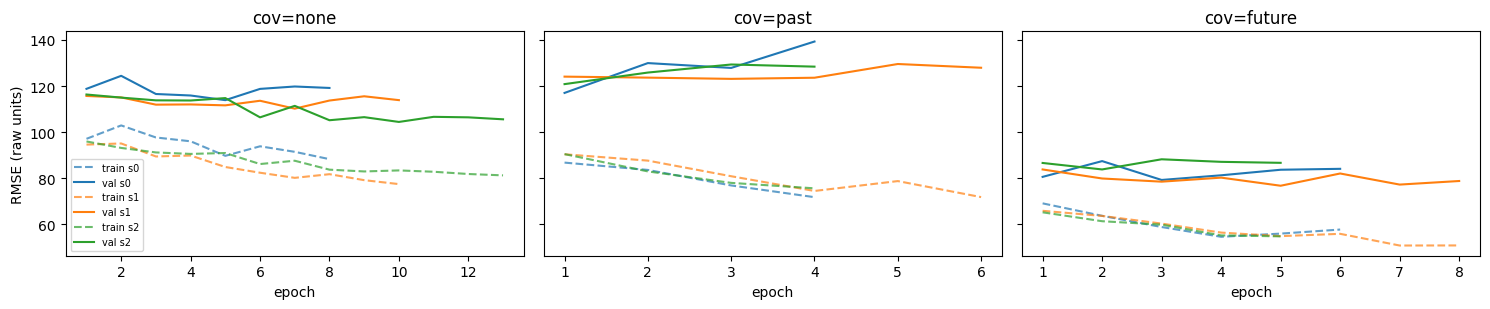

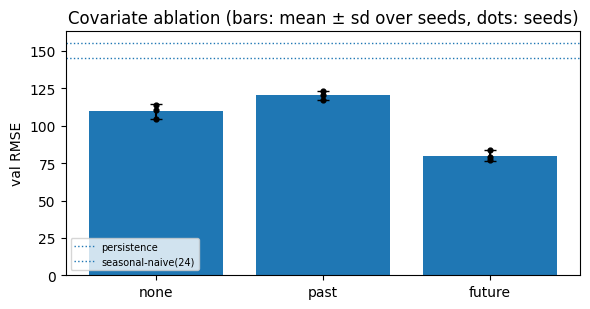

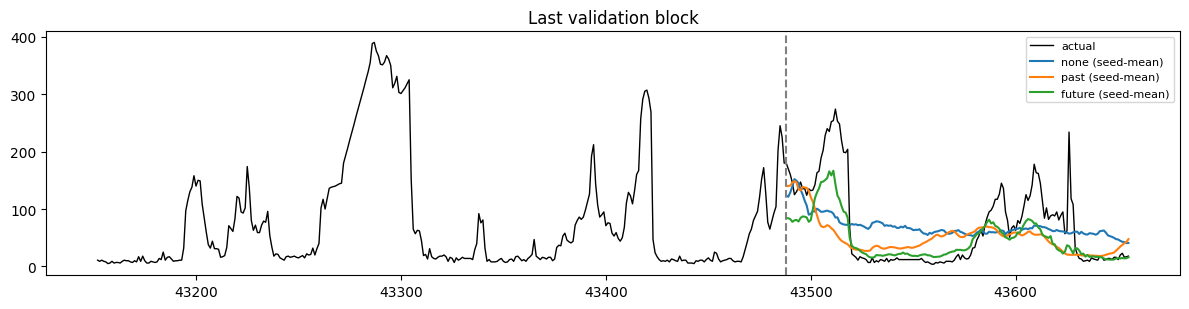

In [13]:
fig, axes = plt.subplots(1, len(COV_MODES), figsize=(5 * len(COV_MODES), 3.2), sharey=True)
for ax, mode in zip(np.atleast_1d(axes), COV_MODES):
    for s in SEEDS:
        h = histories[(mode, s)]
        ax.plot(h.epoch, h.train_RMSE, '--', c=f'C{s}', alpha=0.7, label=f'train s{s}')
        ax.plot(h.epoch, h.val_RMSE, '-', c=f'C{s}', label=f'val s{s}')
    ax.set_title(f'cov={mode}'); ax.set_xlabel('epoch')
np.atleast_1d(axes)[0].set_ylabel('RMSE (raw units)'); np.atleast_1d(axes)[0].legend(fontsize=7)
plt.tight_layout(); plt.savefig(f'{FIG_DIR}/fig_t2_2_learning_curves.pdf'); plt.show()

fig, ax = plt.subplots(figsize=(6, 3.2))
g = res.groupby('mode', sort=False).RMSE
ax.bar(range(len(COV_MODES)), g.mean(), yerr=g.std(), capsize=4, color='C0')
for i, m in enumerate(COV_MODES):
    ax.scatter([i] * len(SEEDS), res.query('mode==@m').RMSE, c='k', s=12, zorder=3)
for _, b in baselines.iterrows():
    ax.axhline(b.RMSE, ls=':', lw=1, label=b['mode'])
ax.set_xticks(range(len(COV_MODES)), COV_MODES); ax.set_ylabel('val RMSE'); ax.legend(fontsize=7)
ax.set_title('Covariate ablation (bars: mean ± sd over seeds, dots: seeds)')
plt.tight_layout(); plt.savefig(f'{FIG_DIR}/fig_t2_3_ablation.pdf'); plt.show()

fig, ax = plt.subplots(figsize=(12, 3.2))
i = blk_idx[-1]; o = val_origins[i]
ax.plot(range(o - 336, o + H), y_raw[o - 336:o + H], c='k', lw=1, label='actual')
for mode in COV_MODES:
    ax.plot(range(o, o + H), np.mean([val_preds[(mode, s)][i] for s in SEEDS], 0), label=f'{mode} (seed-mean)')
ax.axvline(o, ls='--', c='gray'); ax.legend(fontsize=8); ax.set_title('Last validation block')
plt.tight_layout(); plt.savefig(f'{FIG_DIR}/fig_t2_4_val_forecast.pdf'); plt.show()

## 9. Early single-seed refit — not submitted
This was the first refit (best covariate mode, one seed). It was **superseded** by the 3-seed refits in Sections 12, 14 and 15 and was **never submitted**; the P and E it prints were not declared. Its files are written as `early_single_seed_*`.

In [14]:
FINAL_MODE = res.groupby('mode').RMSE.mean().idxmin()
FINAL_SEEDS = SEEDS[:1]          # >1 = seed ensemble (P and E add up)
REFIT = True
print('FINAL_MODE =', FINAL_MODE, '| seeds =', FINAL_SEEDS, '| refit =', REFIT)

y_s_f, cov_f, ysc_f = prepare(N_TRAIN)
full_origins = np.arange(L, N_TRAIN - H + 1, CFG['train_stride'])
final_ds = WindowDataset(y_s_f, cov_f, [N_TRAIN], FINAL_MODE)   # origin = first unseen step (time_idx 43657)

final_preds, P_total, E_total, full_hists = [], 0, 0, {}
for seed in FINAL_SEEDS:
    info = run_info[(FINAL_MODE, seed)]
    if REFIT:
        model, hist, _ = train_model(seed, FINAL_MODE, y_s_f, cov_f, ysc_f, full_origins,
                                     n_epochs=info['best_epoch'], tag=f'[FULL {FINAL_MODE} s{seed}]')
        full_hists[seed] = hist
        E_total += info['epochs_run'] + info['best_epoch']
        pred = predict(model, final_ds, ysc_f)[0]
    else:
        model = build_model(FINAL_MODE); model.load_state_dict(states[(FINAL_MODE, seed)])
        E_total += info['epochs_run']
        pred = predict(model, WindowDataset(y_s_v, cov_v, [N_TRAIN], FINAL_MODE), ysc_v)[0]
    P_total += count_params(model)
    final_preds.append(pred)

if REFIT:
    print('\nFull-training metrics (last epoch, raw units, ~1 window / 168 steps over the whole history):')
    display(pd.DataFrame({s: h.iloc[-1] for s, h in full_hists.items()}).T.round(3))
    # in-sample check on the old validation region (it is training data now, so it is optimistic)
    ins = metrics(predict(model, WindowDataset(y_s_f, cov_f, val_origins, FINAL_MODE), ysc_f), val_true)
    print('In-sample (former val region, last model):', {k: round(v, 2) for k, v in ins.items()})

FINAL_MODE = future | seeds = [0] | refit = True
[FULL future s0] ep 01 | loss 0.2227 | train RMSE 66.56 MAE 41.71 sMAPE 45.8 | 35s
[FULL future s0] ep 02 | loss 0.1759 | train RMSE 60.81 MAE 38.90 sMAPE 42.5 | 35s
[FULL future s0] ep 03 | loss 0.1594 | train RMSE 59.24 MAE 37.36 sMAPE 40.8 | 35s

Full-training metrics (last epoch, raw units, ~1 window / 168 steps over the whole history):


,epoch,loss,lr,train_MAE,train_RMSE,train_sMAPE
0,3.0,0.159,0.001,37.355,59.245,40.772


In-sample (former val region, last model): {'MAE': 37.26, 'RMSE': 59.35, 'sMAPE': 47.33}


Declared P (trainable params) = 117,889
Declared E (total epochs)     = 9
168 values; first = forecast for time_idx 43657

9.1667, 9.4162, 10.0248, 12.8367, 13.8599, 15.8927, 19.7583, 22.8760, 27.4536, 27.3839, 29.7590, 36.1016, 43.5326, 48.5458, 51.9012, 54.9059, 60.0775, 74.8959, 100.3979, 131.2849, 164.4962, 192.8064, 205.1154, 227.4104, 238.7300, 245.9081, 260.4143, 264.6411, 270.6780, 279.3810, 280.7853, 267.8890, 216.6653, 231.6463, 206.2047, 220.5588, 203.7912, 193.8156, 196.1850, 205.0606, 219.9591, 244.1795, 253.0875, 226.7215, 231.6922, 213.3588, 205.2208, 188.8295, 175.4929, 172.0847, 168.9972, 154.9838, 147.3172, 150.0892, 159.2794, 155.1006, 152.6682, 155.3949, 144.1911, 120.6286, 112.8819, 122.3919, 117.1494, 134.3836, 144.6690, 144.4176, 136.2287, 145.8693, 152.5028, 129.3758, 128.7463, 120.3649, 122.4707, 111.0895, 115.7546, 103.5873, 98.7187, 89.5275, 78.3579, 71.3882, 69.9629, 76.7001, 64.3024, 58.5468, 58.1768, 56.8375, 56.2558, 52.4414, 51.0184, 46.6308, 41.4398, 45

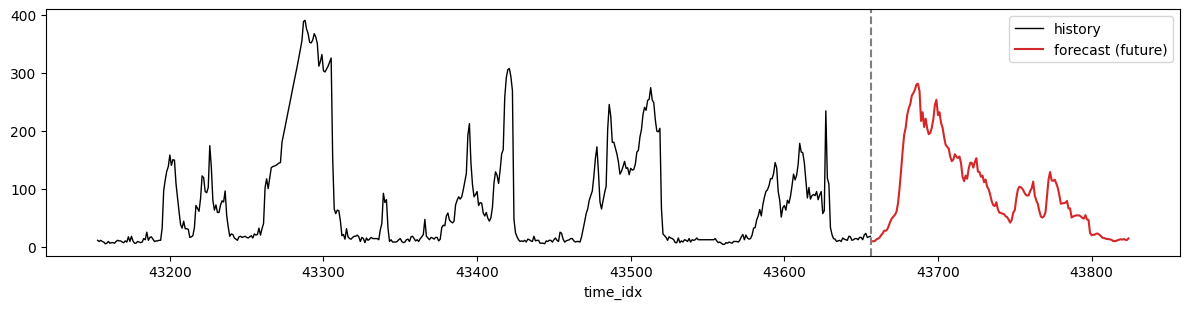

In [15]:
forecast = np.mean(final_preds, axis=0)
assert forecast.shape == (H,) and np.isfinite(forecast).all() and (forecast >= 0).all()

sub = pd.DataFrame({'time_idx': test_df['time_idx'].to_numpy(), 'value': forecast})
assert sub.time_idx.iloc[0] == 43657 and sub.time_idx.iloc[-1] == 43824
sub.to_csv('early_single_seed_forecast.csv', index=False)

submission_str = ', '.join(f'{v:.4f}' for v in forecast)
with open('early_single_seed_string.txt', 'w') as f:
    f.write(submission_str)

print(f'Declared P (trainable params) = {P_total:,}')
print(f'Declared E (total epochs)     = {E_total}')
print(f'{len(forecast)} values; first = forecast for time_idx 43657\n')
print(submission_str)

fig, ax = plt.subplots(figsize=(12, 3.2))
ax.plot(range(N_TRAIN - 3 * H + 1, N_TRAIN + 1), y_raw[-3 * H:], c='k', lw=1, label='history')
ax.plot(sub.time_idx, forecast, c='C3', label=f'forecast ({FINAL_MODE})')
ax.axvline(N_TRAIN + 0.5, ls='--', c='gray'); ax.legend(); ax.set_xlabel('time_idx')
plt.tight_layout(); plt.savefig(f'{FIG_DIR}/fig_t2_early_single_seed_forecast.pdf'); plt.show()

## 10. Second session: reference re-run
The reference configuration of Section 7 (`future` covariates, log target, `d_model=64`) is re-run so that all later comparisons are paired within the same session. It reaches 79.0 ± 2.3 against 80.0 ± 3.6 in Section 7, so the sessions agree.

In [11]:
y_s_v, cov_v, ysc_v = prepare(VAL_START)
val_true = truth(val_origins)
blk_idx = np.searchsorted(val_origins, block_origins)
val_preds, run_info, res_rows = {}, {}, []
for seed in SEEDS:
    model, hist, info = train_model(seed, 'future', y_s_v, cov_v, ysc_v, train_origins, val_origins, tag=f'[future s{seed}]')
    val_preds[('future', seed)] = predict(model, WindowDataset(y_s_v, cov_v, val_origins, 'future'), ysc_v)
    run_info[('future', seed)] = info
    res_rows.append(dict(mode='future', seed=seed, **metrics(val_preds[('future', seed)], val_true), **info))
res = pd.DataFrame(res_rows)

[future s0] ep 01 | loss 0.2248 | train RMSE 65.21 MAE 41.73 sMAPE 45.8 || val RMSE 84.81 MAE 55.49 sMAPE 62.6  * | 37s
[future s0] ep 02 | loss 0.1790 | train RMSE 72.63 MAE 45.08 sMAPE 46.3 || val RMSE 92.28 MAE 58.91 sMAPE 64.5 | 33s
[future s0] ep 03 | loss 0.1619 | train RMSE 61.73 MAE 38.84 sMAPE 41.8 || val RMSE 84.01 MAE 52.71 sMAPE 59.3  * | 34s
[future s0] ep 04 | loss 0.1505 | train RMSE 56.90 MAE 35.20 sMAPE 38.7 || val RMSE 80.08 MAE 48.83 sMAPE 56.5  * | 34s
[future s0] ep 05 | loss 0.1425 | train RMSE 59.92 MAE 36.95 sMAPE 39.1 || val RMSE 85.50 MAE 53.65 sMAPE 60.6 | 34s
[future s0] ep 06 | loss 0.1358 | train RMSE 53.68 MAE 32.86 sMAPE 36.4 || val RMSE 83.10 MAE 50.35 sMAPE 56.5 | 35s
[future s0] ep 07 | loss 0.1298 | train RMSE 55.94 MAE 33.66 sMAPE 35.9 || val RMSE 81.26 MAE 49.87 sMAPE 57.2 | 35s
[future s1] ep 01 | loss 0.2285 | train RMSE 65.80 MAE 43.30 sMAPE 47.4 || val RMSE 81.56 MAE 51.47 sMAPE 58.3  * | 35s
[future s1] ep 02 | loss 0.1830 | train RMSE 68.24 M

## 11. Design experiments: covariate placement and groups, target transform, model size
`run_variant` trains one configuration with all seeds; `summarize` and `paired` compare it seed by seed with a reference. The redefined `WindowDataset` and `build_model` add the `dec` mode (covariates in the decoder only); all other modes behave exactly as before.

In [12]:
class WindowDataset(Dataset):
    # same as before, plus 'dec': covariates enter only through the decoder (label part + horizon)
    def __init__(self, y_s, cov, origins, cov_mode):
        self.y, self.cov, self.origins, self.mode = y_s, cov, np.asarray(origins), cov_mode
    def __len__(self):
        return len(self.origins)
    def __getitem__(self, i):
        o = int(self.origins[i])
        x_enc = self.y[o - L:o, None]
        y_true = self.y[o:o + H, None] if o + H <= len(self.y) else np.zeros((H, 1), np.float32)
        if self.mode == 'none':
            m_enc, m_dec = np.zeros((L, 0), np.float32), np.zeros((LB + H, 0), np.float32)
        else:
            m_enc = self.cov[o - L:o]
            m_dec = self.cov[o - LB:o + H].copy()
            if self.mode == 'past':
                m_dec[LB:] = 0.0
            elif self.mode == 'dec':
                m_enc = np.zeros((L, 0), np.float32)
        return tuple(torch.from_numpy(np.ascontiguousarray(a)) for a in (x_enc, m_enc, m_dec, y_true))

def build_model(cov_mode):
    m = Autoformer(mark_dim=0 if cov_mode == 'none' else len(COV_COLS),
                   d_model=CFG['d_model'], n_heads=CFG['n_heads'], d_ff=CFG['d_ff'],
                   e_layers=CFG['e_layers'], d_layers=CFG['d_layers'], moving_avg=CFG['moving_avg'],
                   factor=CFG['autocorr_factor'], dropout=CFG['dropout'])
    if cov_mode == 'dec':
        m.enc_emb = DataEmbedding(1, 0, CFG['d_model'], CFG['dropout'])
    return m.to(device)

variant_res = []

def run_variant(name, cov_mode='future', cols=None, **cfg_over):
    global COV_COLS, CONT_COLS
    saved = dict(CFG), COV_COLS, CONT_COLS
    CFG.update(cfg_over)
    if cols is not None:
        COV_COLS, CONT_COLS = list(cols), [c for c in cols if c not in BIN_COLS]
    try:
        y_s, cov, ysc = prepare(VAL_START)
        for s in SEEDS:
            model, _, info = train_model(s, cov_mode, y_s, cov, ysc, train_origins, val_origins, tag=f'[{name} s{s}]')
            pred = predict(model, WindowDataset(y_s, cov, val_origins, cov_mode), ysc)
            val_preds[(name, s)], run_info[(name, s)] = pred, info
            variant_res.append(dict(variant=name, seed=s, **metrics(pred, val_true), P=count_params(model), **info))
    finally:
        CFG.clear(); CFG.update(saved[0]); COV_COLS, CONT_COLS = saved[1], saved[2]

def summarize(ref='future'):
    v, rows = pd.DataFrame(variant_res), []
    for name, g in v.groupby('variant', sort=False):
        d = [g.loc[g.seed == s, 'RMSE'].item() - res.loc[(res['mode'] == ref) & (res.seed == s), 'RMSE'].item() for s in g.seed]
        win = np.mean([np.mean(np.sqrt(((val_preds[(name, s)] - val_true) ** 2).mean(1)) <
                               np.sqrt(((val_preds[(ref, s)] - val_true) ** 2).mean(1))) for s in g.seed])
        rows.append(dict(variant=name, RMSE=g.RMSE.mean(), RMSE_sd=g.RMSE.std(), MAE=g.MAE.mean(),
                         sMAPE=g.sMAPE.mean(), dRMSE=np.mean(d), dRMSE_sd=np.std(d, ddof=1),
                         improved=f'{sum(x < 0 for x in d)}/{len(d)}', frac_windows_better=win,
                         P=g.P.iloc[0], epochs_run=g.epochs_run.mean()))
    return pd.DataFrame(rows).round(2)

run_variant('raw-target', target_transform='none')    # does the log1p median bias cost RMSE?
run_variant('dec-only', cov_mode='dec')               # covariates only in the decoder
run_variant('cont-only', cols=CONT_COLS)              # the 6 continuous features
run_variant('binary-only', cols=BIN_COLS)             # the 4 one-hot features
run_variant('small-32', d_model=32, d_ff=64)          # P ~30k: is 118k needed?
summarize()

[raw-target s0] ep 01 | loss 0.2523 | train RMSE 65.68 MAE 47.19 sMAPE 60.0 || val RMSE 76.79 MAE 60.71 sMAPE 79.1  * | 38s
[raw-target s0] ep 02 | loss 0.2142 | train RMSE 62.57 MAE 44.78 sMAPE 60.1 || val RMSE 81.75 MAE 64.29 sMAPE 83.4 | 36s
[raw-target s0] ep 03 | loss 0.1968 | train RMSE 59.05 MAE 41.87 sMAPE 57.2 || val RMSE 81.09 MAE 60.79 sMAPE 82.6 | 36s
[raw-target s0] ep 04 | loss 0.1799 | train RMSE 55.27 MAE 38.56 sMAPE 56.2 || val RMSE 84.55 MAE 63.11 sMAPE 86.6 | 36s
[raw-target s1] ep 01 | loss 0.2520 | train RMSE 64.61 MAE 45.15 sMAPE 59.7 || val RMSE 76.21 MAE 55.61 sMAPE 77.2  * | 36s
[raw-target s1] ep 02 | loss 0.2050 | train RMSE 61.64 MAE 45.87 sMAPE 57.9 || val RMSE 83.49 MAE 66.86 sMAPE 84.6 | 36s
[raw-target s1] ep 03 | loss 0.1846 | train RMSE 54.83 MAE 38.31 sMAPE 54.8 || val RMSE 77.91 MAE 60.30 sMAPE 82.6 | 36s
[raw-target s1] ep 04 | loss 0.1709 | train RMSE 52.79 MAE 36.23 sMAPE 54.6 || val RMSE 79.46 MAE 59.43 sMAPE 85.4 | 36s
[raw-target s2] ep 01 | lo

,variant,RMSE,RMSE_sd,MAE,sMAPE,dRMSE,dRMSE_sd,improved,frac_windows_better,P,epochs_run
0,raw-target,73.70,4.87,55.91,77.21,-5.32,2.60,3/3,0.60,117889,7.33
1,dec-only,87.72,6.74,55.10,59.45,8.70,9.00,0/3,0.51,117249,10.33
2,cont-only,77.88,3.22,51.12,61.61,-1.13,5.39,2/3,0.58,117377,6.00
3,binary-only,89.85,5.40,57.47,65.30,10.83,5.17,0/3,0.30,117121,6.67
4,small-32,76.06,4.17,46.56,54.37,-2.96,5.82,2/3,0.54,30273,7.67


In [13]:
run_variant('raw-small', target_transform='none', d_model=32, d_ff=64)
display(summarize())

def paired(a, b):
    ra = {r['seed']: r['RMSE'] for r in variant_res if r['variant'] == a}
    rb = {r['seed']: r['RMSE'] for r in variant_res if r['variant'] == b}
    d = [ra[s] - rb[s] for s in SEEDS]
    print(f'{a:10s} - {b:10s}: dRMSE {np.mean(d):6.2f} ± {np.std(d, ddof=1):.2f}  ({sum(x < 0 for x in d)}/{len(d)} seeds better)')

paired('raw-small', 'small-32')     # raw vs log target, small model
paired('raw-small', 'raw-target')   # small vs big model, raw target

for name in ['future', 'raw-target', 'small-32', 'raw-small']:
    avg = np.mean([val_preds[(name, s)] for s in SEEDS], 0)
    print(f'{name:10s} 3-seed average:', {k: round(v, 2) for k, v in metrics(avg, val_true).items()})

[raw-small s0] ep 01 | loss 0.2700 | train RMSE 68.39 MAE 50.07 sMAPE 61.5 || val RMSE 82.09 MAE 65.19 sMAPE 83.0  * | 20s
[raw-small s0] ep 02 | loss 0.2271 | train RMSE 66.35 MAE 48.71 sMAPE 60.7 || val RMSE 80.31 MAE 63.54 sMAPE 83.3  * | 19s
[raw-small s0] ep 03 | loss 0.2120 | train RMSE 63.20 MAE 45.24 sMAPE 58.4 || val RMSE 77.87 MAE 61.64 sMAPE 83.7  * | 19s
[raw-small s0] ep 04 | loss 0.2018 | train RMSE 61.85 MAE 45.20 sMAPE 58.7 || val RMSE 76.46 MAE 59.76 sMAPE 82.7  * | 19s
[raw-small s0] ep 05 | loss 0.1958 | train RMSE 59.88 MAE 43.39 sMAPE 58.4 || val RMSE 74.04 MAE 56.04 sMAPE 86.8  * | 19s
[raw-small s0] ep 06 | loss 0.1896 | train RMSE 58.16 MAE 41.38 sMAPE 58.9 || val RMSE 71.48 MAE 51.76 sMAPE 86.9  * | 19s
[raw-small s0] ep 07 | loss 0.1853 | train RMSE 57.32 MAE 40.93 sMAPE 56.8 || val RMSE 70.84 MAE 52.28 sMAPE 83.5  * | 19s
[raw-small s0] ep 08 | loss 0.1810 | train RMSE 56.23 MAE 39.94 sMAPE 56.1 || val RMSE 72.70 MAE 53.93 sMAPE 84.6 | 19s
[raw-small s0] ep 0

,variant,RMSE,RMSE_sd,MAE,sMAPE,dRMSE,dRMSE_sd,improved,frac_windows_better,P,epochs_run
0,raw-target,73.70,4.87,55.91,77.21,-5.32,2.60,3/3,0.60,117889,7.33
1,dec-only,87.72,6.74,55.10,59.45,8.70,9.00,0/3,0.51,117249,10.33
2,cont-only,77.88,3.22,51.12,61.61,-1.13,5.39,2/3,0.58,117377,6.00
3,binary-only,89.85,5.40,57.47,65.30,10.83,5.17,0/3,0.30,117121,6.67
4,small-32,76.06,4.17,46.56,54.37,-2.96,5.82,2/3,0.54,30273,7.67
5,raw-small,71.46,1.96,52.99,83.42,-7.56,2.45,3/3,0.60,30273,11.67


raw-small  - small-32  : dRMSE  -4.60 ± 3.46  (3/3 seeds better)
raw-small  - raw-target: dRMSE  -2.23 ± 4.89  (2/3 seeds better)
future     3-seed average: {'MAE': 46.88, 'RMSE': 74.79, 'sMAPE': 55.2}
raw-target 3-seed average: {'MAE': 53.68, 'RMSE': 70.72, 'sMAPE': 71.11}
small-32   3-seed average: {'MAE': 44.3, 'RMSE': 72.91, 'sMAPE': 51.54}
raw-small  3-seed average: {'MAE': 49.46, 'RMSE': 67.07, 'sMAPE': 71.34}


## 12. Submission #3 — raw-small, 3-seed refit (best leaderboard result)
Raw target, `d_model=32`, all 10 covariates. Each seed is refitted on the full history for its best validation epoch, and the three forecasts are averaged. This cell sets `CFG` to the raw-small values for the rest of the notebook.
Leaderboard: RMSE 74.78, MAE 49.66, sMAPE 60.40 %, P = 90,819, E = 61.

[FULL raw-small s0] ep 01 | loss 0.2716 | train RMSE 70.39 MAE 50.36 sMAPE 61.2 | 20s
[FULL raw-small s0] ep 02 | loss 0.2304 | train RMSE 70.88 MAE 54.17 sMAPE 63.5 | 20s
[FULL raw-small s0] ep 03 | loss 0.2156 | train RMSE 64.55 MAE 47.52 sMAPE 60.6 | 20s
[FULL raw-small s0] ep 04 | loss 0.2065 | train RMSE 64.94 MAE 48.47 sMAPE 61.4 | 20s
[FULL raw-small s0] ep 05 | loss 0.1994 | train RMSE 61.79 MAE 43.65 sMAPE 59.6 | 20s
[FULL raw-small s0] ep 06 | loss 0.1953 | train RMSE 62.20 MAE 45.39 sMAPE 59.6 | 20s
[FULL raw-small s0] ep 07 | loss 0.1925 | train RMSE 62.46 MAE 46.59 sMAPE 60.8 | 20s
[FULL raw-small s0] ep 08 | loss 0.1890 | train RMSE 64.30 MAE 48.90 sMAPE 61.7 | 20s
[FULL raw-small s0] ep 09 | loss 0.1861 | train RMSE 62.41 MAE 47.09 sMAPE 61.4 | 20s
[FULL raw-small s0] ep 10 | loss 0.1845 | train RMSE 60.85 MAE 44.62 sMAPE 59.8 | 19s
[FULL raw-small s0] ep 11 | loss 0.1826 | train RMSE 61.11 MAE 45.43 sMAPE 60.1 | 20s
[FULL raw-small s1] ep 01 | loss 0.2631 | train RMSE 6

,seed,P,val_epochs,refit_epochs,train_MAE,train_RMSE,train_sMAPE
0,0,30273,14,11,45.435,61.114,60.130
1,1,30273,13,10,38.512,54.677,56.309
2,2,30273,8,5,41.733,59.847,57.429


Validation, 3-seed average: {'MAE': 49.46, 'RMSE': 67.07, 'sMAPE': 71.34} | per-week RMSE: [56.4 79.  67.5 77.4 54.8 88.7 63.9 33.6]
values capped at 994: 0
last 5 observed: [20. 23. 16. 17. 18.] | first 5 forecast: [13.3 14.2 11.6 18.3 16.1]


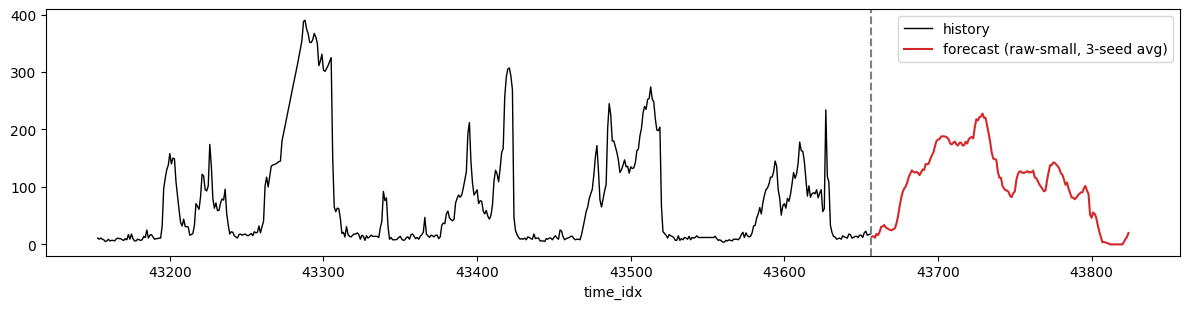


Declared P = 90,819   Declared E = 61
13.3412, 14.1865, 11.6467, 18.2992, 16.1087, 21.3776, 30.3897, 31.3287, 33.6236, 29.4867, 27.7213, 26.3559, 24.9141, 24.4734, 26.6819, 27.9779, 36.3591, 49.0146, 65.4538, 80.0874, 90.7147, 97.1681, 100.5669, 107.8583, 117.3959, 122.9669, 128.6640, 125.9733, 124.9035, 126.1309, 124.3923, 120.4120, 125.2658, 130.2844, 129.4921, 140.0055, 139.0884, 140.7453, 148.4355, 154.6682, 159.8175, 170.1828, 179.7138, 182.4222, 183.1265, 187.6873, 188.1870, 187.8622, 187.5204, 185.7395, 182.3477, 175.4536, 173.8068, 176.8440, 178.9456, 174.0183, 172.0291, 176.7592, 177.1976, 172.2284, 172.4678, 178.5518, 175.4824, 182.4973, 185.7499, 186.8558, 184.5973, 204.5588, 217.8493, 215.5284, 221.5170, 222.5182, 227.6135, 220.0373, 220.1984, 206.4377, 193.0577, 177.6660, 159.5637, 149.2827, 148.2710, 146.9565, 126.0717, 116.0387, 115.9634, 101.5795, 97.2303, 94.2275, 93.5831, 90.9875, 84.2285, 82.2036, 89.1675, 91.8175, 111.4528, 121.8947, 126.7366, 126.8691, 124.4163, 1

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [14]:
import json, zipfile, glob

# ===== Final: raw target, d_model=32, all 10 covariates in encoder + decoder, 3-seed average =====
FINAL_VARIANT = 'raw-small'
CFG.update(target_transform='none', d_model=32, d_ff=64)    # permanent from here on
FINAL_MODE, FINAL_SEEDS = 'future', SEEDS
CAP = float(y_raw.max())                                     # never forecast above the observed maximum

y_s_f, cov_f, ysc_f = prepare(N_TRAIN)
full_origins = np.arange(L, N_TRAIN - H + 1, CFG['train_stride'])
final_ds = WindowDataset(y_s_f, cov_f, [N_TRAIN], FINAL_MODE)   # forecasts time_idx 43657..43824

final_preds, P_total, E_total, members = [], 0, 0, []
for seed in FINAL_SEEDS:
    info = run_info[(FINAL_VARIANT, seed)]
    model, hist, _ = train_model(seed, FINAL_MODE, y_s_f, cov_f, ysc_f, full_origins,
                                 n_epochs=info['best_epoch'], tag=f'[FULL {FINAL_VARIANT} s{seed}]')
    p = count_params(model)
    final_preds.append(predict(model, final_ds, ysc_f)[0])
    P_total += p
    E_total += info['epochs_run'] + info['best_epoch']          # validation run + refit (Sec. 2.7)
    members.append(dict(seed=seed, P=p, val_epochs=info['epochs_run'], refit_epochs=info['best_epoch'],
                        **{k: round(float(v), 3) for k, v in hist.iloc[-1].items() if k.startswith('train_')}))
    torch.save(model.state_dict(), f'final_{FINAL_VARIANT}_s{seed}.pt')
    hist.to_csv(f'final_{FINAL_VARIANT}_s{seed}_history.csv', index=False)

members = pd.DataFrame(members)
print('\nFull-training metrics per member (last refit epoch, raw units):')
display(members)

avg_val = np.mean([val_preds[(FINAL_VARIANT, s)] for s in FINAL_SEEDS], 0)
wk = [metrics(avg_val[j], val_true[j])['RMSE'] for j in blk_idx]
print('Validation, 3-seed average:', {k: round(v, 2) for k, v in metrics(avg_val, val_true).items()},
      '| per-week RMSE:', np.round(wk, 1))

raw_forecast = np.mean(final_preds, axis=0)
forecast = np.clip(raw_forecast, 0, CAP)
print(f'values capped at {CAP:.0f}: {int((raw_forecast > CAP).sum())}')
assert forecast.shape == (H,) and np.isfinite(forecast).all()
print('last 5 observed:', y_raw[-5:], '| first 5 forecast:', np.round(forecast[:5], 1))

sub = pd.DataFrame({'time_idx': test_df['time_idx'].to_numpy(), 'value': forecast})
assert sub.time_idx.iloc[0] == 43657 and sub.time_idx.iloc[-1] == 43824
sub.to_csv('submission_forecast.csv', index=False)
submission_str = ', '.join(f'{v:.4f}' for v in forecast)
open('submission_string.txt', 'w').write(submission_str)

with open('final_declared.json', 'w') as f:
    json.dump(dict(variant=FINAL_VARIANT, cov_mode=FINAL_MODE, seeds=FINAL_SEEDS, P=int(P_total), E=int(E_total),
                   cfg=CFG, cov_cols=COV_COLS, members=members.to_dict('records')), f, indent=2,
              default=lambda o: o.item() if hasattr(o, 'item') else str(o))
res.to_csv('ablation_future_runs.csv', index=False)
pd.DataFrame(variant_res).to_csv('ablation_variant_runs.csv', index=False)
summarize().to_csv('ablation_summary.csv', index=False)

fig, ax = plt.subplots(figsize=(12, 3.2))
ax.plot(range(N_TRAIN - 3 * H + 1, N_TRAIN + 1), y_raw[-3 * H:], c='k', lw=1, label='history')
ax.plot(sub.time_idx, forecast, c='C3', label='forecast (raw-small, 3-seed avg)')
ax.axvline(N_TRAIN + 0.5, ls='--', c='gray'); ax.legend(); ax.set_xlabel('time_idx')
plt.tight_layout(); plt.savefig(f'{FIG_DIR}/fig_t2_5_final_forecast.pdf'); plt.show()

print(f'\nDeclared P = {P_total:,}   Declared E = {E_total}')
print(submission_str)

with zipfile.ZipFile('task2_outputs.zip', 'w') as z:
    for fn in glob.glob('final_*') + glob.glob('ablation_*.csv') + glob.glob('submission_*') + glob.glob(f'{FIG_DIR}/*'):
        z.write(fn)
from google.colab import files; files.download('task2_outputs.zip')

## 13. Feature-engineering experiments
New covariates computed only from the external file and the time index (so they are known over the horizon): time-phase features (`fe-time`), dynamics features (`fe-dyn`: 6-step change and centred 24-step rolling mean of the 6 continuous variables), and both (`fe-all`).

In the recorded run, the next cell was **interrupted by an accidental key press** during `fe-all` seed 2 (traceback below). `fe-time`, `fe-dyn` and `fe-all` seeds 0–1 had finished and were stored. The cell after it completes only the missing `fe-all` seed and then tests the MSE loss on `fe-dyn`.

In [15]:
# engineered covariates: computed only from the external file / time index, so known over the horizon
t = ext_df['time_idx'].to_numpy(dtype=float)
ext_df['tod_sin'], ext_df['tod_cos'] = np.sin(2 * np.pi * t / 24), np.cos(2 * np.pi * t / 24)
ext_df['yr_sin'], ext_df['yr_cos'] = np.sin(2 * np.pi * t / 8766), np.cos(2 * np.pi * t / 8766)
TIME_FE = ['tod_sin', 'tod_cos', 'yr_sin', 'yr_cos']

DYN_FE = []
for c in CONT_COLS:
    ext_df[f'{c}_d6'] = ext_df[c].diff(6).fillna(0)                                 # change over 6 steps
    ext_df[f'{c}_ma24'] = ext_df[c].rolling(24, center=True, min_periods=1).mean()   # smoothed level
    DYN_FE += [f'{c}_d6', f'{c}_ma24']

BASE_COLS = list(COV_COLS)
RAW_SMALL = dict(target_transform='none', d_model=32, d_ff=64)
run_variant('fe-time', cols=BASE_COLS + TIME_FE, **RAW_SMALL)
run_variant('fe-dyn', cols=BASE_COLS + DYN_FE, **RAW_SMALL)
run_variant('fe-all', cols=BASE_COLS + TIME_FE + DYN_FE, **RAW_SMALL)

for v in ['fe-time', 'fe-dyn', 'fe-all']:
    paired(v, 'raw-small')
for name in ['raw-small', 'fe-time', 'fe-dyn', 'fe-all']:
    avg = np.mean([val_preds[(name, s)] for s in SEEDS], 0)
    print(f'{name:10s} 3-seed average:', {k: round(v, 2) for k, v in metrics(avg, val_true).items()})

[fe-time s0] ep 01 | loss 0.2513 | train RMSE 66.61 MAE 46.58 sMAPE 60.0 || val RMSE 71.63 MAE 55.67 sMAPE 75.5  * | 20s
[fe-time s0] ep 02 | loss 0.2083 | train RMSE 63.41 MAE 44.78 sMAPE 59.4 || val RMSE 70.90 MAE 52.25 sMAPE 72.5  * | 20s
[fe-time s0] ep 03 | loss 0.1921 | train RMSE 61.42 MAE 43.12 sMAPE 60.3 || val RMSE 69.66 MAE 52.10 sMAPE 73.8  * | 19s
[fe-time s0] ep 04 | loss 0.1823 | train RMSE 59.55 MAE 41.02 sMAPE 62.4 || val RMSE 68.93 MAE 49.46 sMAPE 75.2  * | 19s
[fe-time s0] ep 05 | loss 0.1765 | train RMSE 58.71 MAE 41.73 sMAPE 63.4 || val RMSE 69.05 MAE 50.67 sMAPE 82.2 | 19s
[fe-time s0] ep 06 | loss 0.1715 | train RMSE 58.14 MAE 40.46 sMAPE 62.9 || val RMSE 68.64 MAE 48.68 sMAPE 82.4  * | 19s
[fe-time s0] ep 07 | loss 0.1679 | train RMSE 57.05 MAE 39.79 sMAPE 63.5 || val RMSE 68.52 MAE 48.92 sMAPE 81.0  * | 19s
[fe-time s0] ep 08 | loss 0.1647 | train RMSE 56.31 MAE 39.41 sMAPE 62.4 || val RMSE 68.11 MAE 48.54 sMAPE 80.5  * | 19s
[fe-time s0] ep 09 | loss 0.1625 | 

KeyboardInterrupt: 

In [16]:
# 1) finish fe-all: in the recorded run only seed 2 was interrupted (seeds 0 and 1 were already stored).
#    On an uninterrupted run nothing is missing, so this step is skipped.
_done = {r['seed'] for r in variant_res if r['variant'] == 'fe-all'}
_missing = [s for s in SEEDS if s not in _done]
if _missing:
    _all_seeds = SEEDS
    SEEDS = _missing
    try:
        run_variant('fe-all', cols=BASE_COLS + TIME_FE + DYN_FE, **RAW_SMALL)
    finally:
        SEEDS = _all_seeds

# 2) loss matched to the leaderboard metric, on the best feature set so far
run_variant('fe-dyn-mse', cols=BASE_COLS + DYN_FE, huber_delta=100.0, **RAW_SMALL)

for v in ['fe-time', 'fe-dyn', 'fe-all']:
    paired(v, 'raw-small')
paired('fe-all', 'fe-dyn')
paired('fe-dyn-mse', 'fe-dyn')
for name in ['raw-small', 'fe-time', 'fe-dyn', 'fe-all', 'fe-dyn-mse']:
    avg = np.mean([val_preds[(name, s)] for s in SEEDS], 0)
    print(f'{name:11s} 3-seed average:', {k: round(v, 2) for k, v in metrics(avg, val_true).items()})

[fe-all s2] ep 01 | loss 0.2359 | train RMSE 61.58 MAE 43.07 sMAPE 58.3 || val RMSE 70.77 MAE 54.34 sMAPE 73.5  * | 20s
[fe-all s2] ep 02 | loss 0.1897 | train RMSE 60.14 MAE 42.97 sMAPE 58.4 || val RMSE 71.68 MAE 55.45 sMAPE 77.5 | 20s
[fe-all s2] ep 03 | loss 0.1740 | train RMSE 56.57 MAE 39.73 sMAPE 57.8 || val RMSE 72.17 MAE 56.02 sMAPE 78.9 | 20s
[fe-all s2] ep 04 | loss 0.1636 | train RMSE 54.72 MAE 37.66 sMAPE 59.6 || val RMSE 71.02 MAE 53.37 sMAPE 79.4 | 20s
[fe-dyn-mse s0] ep 01 | loss 0.3181 | train RMSE 64.23 MAE 46.88 sMAPE 62.1 || val RMSE 84.45 MAE 67.71 sMAPE 84.5  * | 20s
[fe-dyn-mse s0] ep 02 | loss 0.2478 | train RMSE 61.51 MAE 44.45 sMAPE 62.2 || val RMSE 77.98 MAE 60.90 sMAPE 80.3  * | 20s
[fe-dyn-mse s0] ep 03 | loss 0.2242 | train RMSE 58.16 MAE 41.71 sMAPE 61.4 || val RMSE 72.97 MAE 55.93 sMAPE 82.1  * | 20s
[fe-dyn-mse s0] ep 04 | loss 0.2080 | train RMSE 56.24 MAE 40.59 sMAPE 58.9 || val RMSE 72.88 MAE 56.58 sMAPE 81.1  * | 20s
[fe-dyn-mse s0] ep 05 | loss 0.19

## 14. Submission #4 — fe-dyn, 3-seed refit
Leaderboard: RMSE 76.94, MAE 53.06, sMAPE 67.53 %, P = 93,123, E = 29.

In [17]:
import json, zipfile, glob

def final_refit(variant, cols, **cfg_over):
    # refit each seed of a validated variant on the full history for its own best_epoch
    global COV_COLS, CONT_COLS
    saved = dict(CFG), COV_COLS, CONT_COLS
    CFG.update(cfg_over)
    COV_COLS, CONT_COLS = list(cols), [c for c in cols if c not in BIN_COLS]
    try:
        y_s_f, cov_f, ysc_f = prepare(N_TRAIN)
        full_origins = np.arange(L, N_TRAIN - H + 1, CFG['train_stride'])
        final_ds = WindowDataset(y_s_f, cov_f, [N_TRAIN], 'future')
        preds, members = [], []
        for seed in SEEDS:
            info = run_info[(variant, seed)]
            model, hist, _ = train_model(seed, 'future', y_s_f, cov_f, ysc_f, full_origins,
                                         n_epochs=info['best_epoch'], tag=f'[FULL {variant} s{seed}]')
            preds.append(predict(model, final_ds, ysc_f)[0])
            members.append(dict(seed=seed, P=count_params(model), val_epochs=info['epochs_run'],
                                refit_epochs=info['best_epoch'],
                                **{k: round(float(v), 3) for k, v in hist.iloc[-1].items() if k.startswith('train_')}))
            torch.save(model.state_dict(), f'final_{variant}_s{seed}.pt')
            hist.to_csv(f'final_{variant}_s{seed}_history.csv', index=False)
        cfg_used = dict(CFG)
    finally:
        CFG.clear(); CFG.update(saved[0]); COV_COLS, CONT_COLS = saved[1], saved[2]
    members = pd.DataFrame(members)
    P, E = int(members.P.sum()), int((members.val_epochs + members.refit_epochs).sum())
    return np.mean(preds, 0), members, P, E, cfg_used

def write_submission(name, forecast, members, P, E, cfg_used, cols):
    forecast = np.clip(forecast, 0, float(y_raw.max()))
    assert forecast.shape == (H,) and np.isfinite(forecast).all()
    s = ', '.join(f'{v:.4f}' for v in forecast)
    open(f'submission_string_{name}.txt', 'w').write(s)
    pd.DataFrame({'time_idx': test_df['time_idx'].to_numpy(), 'value': forecast}).to_csv(
        f'submission_forecast_{name}.csv', index=False)
    with open(f'final_declared_{name}.json', 'w') as f:
        json.dump(dict(variant=name, P=P, E=E, cfg=cfg_used, cov_cols=list(cols), members=members.to_dict('records')),
                  f, indent=2, default=lambda o: o.item() if hasattr(o, 'item') else str(o))
    display(members)
    print('last 5 observed:', y_raw[-5:], '| first 5 forecast:', np.round(forecast[:5], 1))
    print(f'{name}: Declared P = {P:,}   Declared E = {E}   | values = {len(forecast)}')
    print(s)
    return forecast

FE_DYN_COLS = BASE_COLS + DYN_FE
fc, mem, P4, E4, cfg4 = final_refit('fe-dyn', FE_DYN_COLS, **RAW_SMALL)
avg_val = np.mean([val_preds[('fe-dyn', s)] for s in SEEDS], 0)
print('validation 3-seed avg:', {k: round(v, 2) for k, v in metrics(avg_val, val_true).items()},
      '| per-week RMSE:', np.round([metrics(avg_val[j], val_true[j])['RMSE'] for j in blk_idx], 1))
forecast_4 = write_submission('fe-dyn', fc, mem, P4, E4, cfg4, FE_DYN_COLS)

pd.DataFrame(variant_res).to_csv('ablation_variant_runs.csv', index=False)
with zipfile.ZipFile('task2_outputs_fe_dyn.zip', 'w') as z:
    for fn in glob.glob('final_*') + glob.glob('submission_*') + glob.glob('ablation_*.csv') + glob.glob(f'{FIG_DIR}/*'):
        z.write(fn)
from google.colab import files; files.download('task2_outputs_fe_dyn.zip')

[FULL fe-dyn s0] ep 01 | loss 0.2524 | train RMSE 64.98 MAE 44.63 sMAPE 62.1 | 21s
[FULL fe-dyn s0] ep 02 | loss 0.2039 | train RMSE 62.79 MAE 44.87 sMAPE 58.5 | 21s
[FULL fe-dyn s0] ep 03 | loss 0.1882 | train RMSE 59.00 MAE 41.74 sMAPE 59.7 | 20s
[FULL fe-dyn s0] ep 04 | loss 0.1760 | train RMSE 56.79 MAE 40.08 sMAPE 60.0 | 20s
[FULL fe-dyn s0] ep 05 | loss 0.1673 | train RMSE 55.01 MAE 37.75 sMAPE 62.9 | 20s
[FULL fe-dyn s0] ep 06 | loss 0.1611 | train RMSE 53.93 MAE 37.79 sMAPE 58.6 | 20s
[FULL fe-dyn s1] ep 01 | loss 0.2567 | train RMSE 67.53 MAE 48.55 sMAPE 60.6 | 21s
[FULL fe-dyn s1] ep 02 | loss 0.2132 | train RMSE 59.24 MAE 40.50 sMAPE 61.4 | 20s
[FULL fe-dyn s1] ep 03 | loss 0.1943 | train RMSE 56.21 MAE 38.28 sMAPE 60.2 | 20s
[FULL fe-dyn s2] ep 01 | loss 0.2654 | train RMSE 67.20 MAE 44.55 sMAPE 63.5 | 20s
validation 3-seed avg: {'MAE': 47.42, 'RMSE': 63.49, 'sMAPE': 69.35} | per-week RMSE: [57.1 67.  73.3 67.7 55.4 79.1 59.  49.9]


,seed,P,val_epochs,refit_epochs,train_MAE,train_RMSE,train_sMAPE
0,0,31041,9,6,37.795,53.928,58.611
1,1,31041,6,3,38.278,56.212,60.239
2,2,31041,4,1,44.549,67.201,63.498


last 5 observed: [20. 23. 16. 17. 18.] | first 5 forecast: [4.5 7.9 6.2 9.8 6.8]
fe-dyn: Declared P = 93,123   Declared E = 29   | values = 168
4.4621, 7.8781, 6.2104, 9.7703, 6.7695, 8.0934, 17.7180, 15.9768, 17.5563, 11.0642, 14.5422, 15.0306, 14.5736, 15.0075, 15.8806, 17.7006, 18.9030, 30.7729, 40.6268, 60.8723, 71.7306, 84.8003, 90.5059, 99.4944, 106.7748, 105.3059, 109.9568, 110.1018, 110.3703, 111.5441, 111.1248, 110.7502, 114.8719, 121.9725, 135.6033, 147.2639, 150.4898, 152.4134, 155.7266, 150.9589, 155.2645, 159.0341, 176.0372, 178.1025, 185.1039, 187.7115, 188.5907, 189.2673, 183.6779, 184.6790, 174.2422, 170.9383, 162.8415, 162.3332, 161.2227, 159.8362, 154.6152, 169.0904, 170.6691, 163.7544, 159.5118, 164.2416, 166.0644, 161.0258, 164.3074, 171.5322, 181.8829, 192.6521, 204.2989, 211.5048, 222.9268, 218.9564, 217.9212, 212.4908, 210.4263, 198.3874, 173.6866, 167.8490, 154.4749, 143.6221, 135.7185, 140.4237, 120.8833, 113.3216, 109.2492, 95.5420, 88.0129, 75.5985, 78.8477, 

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 15. Submission #5 — 0.75 × fe-dyn + 0.25 × log-target fe-dyn
The first cell trains the log-target fe-dyn variant and compares blend weights on validation; the second refits the log members and writes the blend.
Leaderboard: RMSE 79.16, MAE 53.67, sMAPE 59.60 %, P = 186,246, E = 54.

In [18]:
LOG_SMALL = dict(target_transform='log1p', d_model=32, d_ff=64)
run_variant('fe-dyn-log', cols=BASE_COLS + DYN_FE, **LOG_SMALL)
paired('fe-dyn-log', 'small-32')          # do the dynamics features help the log model too?

A = np.mean([val_preds[('fe-dyn', s)] for s in SEEDS], 0)
B = np.mean([val_preds[('fe-dyn-log', s)] for s in SEEDS], 0)
wk = lambda P_: np.array([metrics(P_[j], val_true[j])['RMSE'] for j in blk_idx])
for w in [1.0, 0.75, 0.5]:
    P_ = w * A + (1 - w) * B
    print(f'w_raw={w:.2f}', {k: round(v, 2) for k, v in metrics(P_, val_true).items()},
          f'| weeks better than fe-dyn: {(wk(P_) < wk(A)).sum()}/8')

[fe-dyn-log s0] ep 01 | loss 0.2243 | train RMSE 66.34 MAE 41.67 sMAPE 45.4 || val RMSE 77.65 MAE 49.78 sMAPE 57.1  * | 19s
[fe-dyn-log s0] ep 02 | loss 0.1777 | train RMSE 60.06 MAE 37.10 sMAPE 41.0 || val RMSE 76.09 MAE 47.41 sMAPE 55.3  * | 20s
[fe-dyn-log s0] ep 03 | loss 0.1631 | train RMSE 58.43 MAE 36.86 sMAPE 40.2 || val RMSE 73.90 MAE 44.93 sMAPE 51.9  * | 20s
[fe-dyn-log s0] ep 04 | loss 0.1540 | train RMSE 55.82 MAE 34.69 sMAPE 38.5 || val RMSE 77.22 MAE 47.19 sMAPE 55.1 | 20s
[fe-dyn-log s0] ep 05 | loss 0.1475 | train RMSE 54.59 MAE 34.23 sMAPE 38.0 || val RMSE 75.94 MAE 46.82 sMAPE 54.5 | 20s
[fe-dyn-log s0] ep 06 | loss 0.1423 | train RMSE 56.13 MAE 34.62 sMAPE 37.3 || val RMSE 76.11 MAE 46.22 sMAPE 53.4 | 20s
[fe-dyn-log s1] ep 01 | loss 0.2248 | train RMSE 64.33 MAE 40.72 sMAPE 44.9 || val RMSE 84.46 MAE 51.35 sMAPE 58.4  * | 20s
[fe-dyn-log s1] ep 02 | loss 0.1759 | train RMSE 60.94 MAE 37.85 sMAPE 41.5 || val RMSE 80.42 MAE 50.09 sMAPE 58.1  * | 20s
[fe-dyn-log s1] e

In [19]:
fc_log, mem_log, P_log, E_log, cfg_log = final_refit('fe-dyn-log', FE_DYN_COLS, **LOG_SMALL)

W = 0.75                                   # chosen on validation (1.0 / 0.75 / 0.5 compared above)
blend = W * forecast_4 + (1 - W) * np.clip(fc_log, 0, float(y_raw.max()))
mem5 = pd.concat([mem.assign(variant='fe-dyn'), mem_log.assign(variant='fe-dyn-log')], ignore_index=True)
forecast_5 = write_submission('blend75', blend, mem5, P4 + P_log, E4 + E_log,
                              dict(raw=cfg4, log=cfg_log, w_raw=W), FE_DYN_COLS)

pd.DataFrame(variant_res).to_csv('ablation_variant_runs.csv', index=False)
with zipfile.ZipFile('task2_outputs_final.zip', 'w') as z:
    for fn in glob.glob('final_*') + glob.glob('submission_*') + glob.glob('ablation_*.csv') + glob.glob(f'{FIG_DIR}/*'):
        z.write(fn)
from google.colab import files; files.download('task2_outputs_final.zip')

[FULL fe-dyn-log s0] ep 01 | loss 0.2215 | train RMSE 66.16 MAE 40.89 sMAPE 45.2 | 21s
[FULL fe-dyn-log s0] ep 02 | loss 0.1752 | train RMSE 60.84 MAE 37.84 sMAPE 41.5 | 21s
[FULL fe-dyn-log s0] ep 03 | loss 0.1615 | train RMSE 58.64 MAE 35.71 sMAPE 39.8 | 20s
[FULL fe-dyn-log s1] ep 01 | loss 0.2200 | train RMSE 66.01 MAE 41.27 sMAPE 45.3 | 20s
[FULL fe-dyn-log s1] ep 02 | loss 0.1743 | train RMSE 59.73 MAE 37.22 sMAPE 41.4 | 20s
[FULL fe-dyn-log s2] ep 01 | loss 0.2250 | train RMSE 63.88 MAE 40.27 sMAPE 44.2 | 20s
[FULL fe-dyn-log s2] ep 02 | loss 0.1734 | train RMSE 59.86 MAE 37.13 sMAPE 40.9 | 21s
[FULL fe-dyn-log s2] ep 03 | loss 0.1569 | train RMSE 56.65 MAE 35.32 sMAPE 39.3 | 21s


,seed,P,val_epochs,refit_epochs,train_MAE,train_RMSE,train_sMAPE,variant
0,0,31041,9,6,37.795,53.928,58.611,fe-dyn
1,1,31041,6,3,38.278,56.212,60.239,fe-dyn
2,2,31041,4,1,44.549,67.201,63.498,fe-dyn
3,0,31041,6,3,35.707,58.639,39.765,fe-dyn-log
4,1,31041,5,2,37.219,59.728,41.435,fe-dyn-log
5,2,31041,6,3,35.321,56.645,39.330,fe-dyn-log


last 5 observed: [20. 23. 16. 17. 18.] | first 5 forecast: [ 6.9  9.6  8.5 11.7  9.3]
blend75: Declared P = 186,246   Declared E = 54   | values = 168
6.9315, 9.6407, 8.4573, 11.6752, 9.2554, 10.3833, 18.4709, 17.4018, 18.8474, 13.5818, 16.4644, 17.0796, 16.9370, 17.3115, 18.4118, 20.4507, 22.7097, 32.9649, 41.1566, 59.1490, 69.2580, 79.8288, 84.5822, 92.7000, 100.3059, 98.3513, 104.0615, 106.0967, 107.9844, 109.6287, 109.5546, 108.9324, 111.0392, 118.4134, 130.6907, 143.9623, 145.0282, 145.4310, 147.3662, 141.6628, 146.0493, 150.5695, 168.2329, 168.7667, 175.1521, 175.8904, 175.7754, 173.8861, 167.3627, 168.3399, 158.6644, 155.5900, 147.6456, 147.8364, 147.4323, 145.9810, 140.4368, 153.7625, 153.9663, 146.8670, 142.6824, 147.8441, 150.2409, 145.6726, 150.9662, 159.3078, 169.5246, 181.4981, 193.7602, 200.5871, 213.2709, 207.2393, 207.6613, 203.2135, 203.5591, 187.9902, 161.0601, 155.0285, 141.1045, 129.9449, 121.6710, 126.4345, 107.7477, 100.0115, 94.5779, 83.2465, 76.8457, 66.2000, 69

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 16. Summary of submissions

| # | Model | Val. RMSE (3-seed ens.) | Test RMSE | Test MAE | Test sMAPE | P | E |
|---|---|---|---|---|---|---|---|
| 1 | standard Autoformer (thuml port, separate notebook) | – | 105.59 | 69.59 | 78.01 % | 70,275 | 12 |
| 2 | standard Autoformer (thuml port, separate notebook) | – | 90.26 | 62.93 | 65.84 % | 506,118 | 33 |
| **3** | **raw-small (Section 12)** | 67.07 | **74.78** | **49.66** | 60.40 % | 90,819 | 61 |
| 4 | fe-dyn (Section 14) | 63.49 | 76.94 | 53.06 | 67.53 % | 93,123 | 29 |
| 5 | 0.75 fe-dyn + 0.25 log fe-dyn (Section 15) | 63.88 | 79.16 | 53.67 | 59.60 % | 186,246 | 54 |

The leaderboard counts the best attempt, which is #3.